# **Exploring Logical Regression to Predict Registration**

This notebook performs a comprehensive analysis and predictive modelling on student enrolment data with a focus on registration outcomes.

The main steps are as follows:

- **Data Loading & Preprocessing:**  
    The dataset is loaded from an Excel file that was cleaned by Berverly, that has Discount Types grouped. Here specific date columns are parsed. It is then filtered to include only students who have been offered a course. Rare nationalities are identified and replaced with "Other", and dummy variables are created for the "Completed" status.

- **Data Aggregation & Feature Engineering:**  
    Categorical variables are encoded using one-hot encoding to be used in modelling. The data is aggregated at the student level, and key features such as discount, centre, programme, area, and net value are extracted.

- **Train-Test Splitting and Balancing:**  
    The dataset is split into training and test sets. Due to class imbalances in the registration target, the training set is balanced using resampling techniques.

- **Feature Scaling:**  
    Numeric features are standardised to ensure fair weighting during model training.

- **Model Training & Evaluation:**  
    Two logistic regression models are developed:
    1. **Full Model:** Trained on all available features.
    2. **Important Features Model:** Trained on a subset of features identified as most influential based on the model’s coefficients.
    
    Both models are evaluated using metrics such as accuracy, ROC AUC, confusion matrices, and ROC curves. Visualisations support the comparison and analysis of model performance.

- **Additional Visual Analyses:**  
    At the end of the notebook I've included scatterplots, boxplots, and cross-validation score plots to explore relationships (for example, discount vs. net value) and validate model performance further.

**Data Loading & Preprocessing:**

In [ ]:
# Standard library and third-party imports.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import warnings

# Scikit-learn imports.
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
)
from sklearn.utils import resample

# Statsmodels import.
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Ensure that plots appear inline in the notebook.
%matplotlib inline

**Loading data from Excel and parsing date columns ensures that all time-related features are correctly interpreted (Note that parsing isn't needed, but done for good habit):**

In [ ]:
# Load the dataset. Specify date columns that need to be parsed for proper handling.
date_cols = [
    'Application Date',
    'Offered Date',
    'Confirmation Date',
    'Arrived Date',
    'Cancellation Date'
]

# Read Excel file with date parsing and assign to studygroup dataframe.
studygroup = pd.read_excel(
    'sg_studentdata_cleaned.xlsx',
    parse_dates=date_cols
)


**Filtering to include only students who were offered a course refines the dataset focus to relevant cases:**

In [ ]:
# Filter the dataset to keep only students that were offered.
studygroup = studygroup[studygroup['Offered Date'].notnull()]

# Quick look at the data structure.
print(studygroup.info())


<class 'pandas.core.frame.DataFrame'>
Index: 51892 entries, 1 to 71753
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Centre             51892 non-null  object        
 1   Programme          51892 non-null  object        
 2   Area               51892 non-null  object        
 3   Region             51892 non-null  object        
 4   Sub Region         51397 non-null  object        
 5   Country            51892 non-null  object        
 6   Branch URN         51892 non-null  object        
 7   Group URN          51892 non-null  object        
 8   Lead Source        51892 non-null  object        
 9   Student ID         51892 non-null  int64         
 10  Booking ID         51892 non-null  int64         
 11  Nationality        51892 non-null  object        
 12  IntakeYear         51892 non-null  int64         
 13  IntakeQuarter      51892 non-null  int64         
 14  Application

**Replacing rare nationalities (those below a threshold, of less then 1% of the total population) with "Other" avoids overfitting and simplifies categorical encoding. This was done in response to feedback from Study Group:**

In [ ]:
# Calculate the total number of rows.
total_count = len(studygroup)

# Calculate the frequency of each Nationality
nationality_counts = studygroup['Nationality'].value_counts()

# Compute the threshold.
threshold_percentage = 0.005
threshold_count = total_count * threshold_percentage

# Identify Nationalities with fewer than that threshold_count.
under_threshold = nationality_counts[
    nationality_counts < threshold_count
].index

# Duplicate the 'Nationality' column for reference.
studygroup['Nationality_original'] = studygroup['Nationality']

# Replace the nationalities under the threshold with 'Other'.
studygroup.loc[
    studygroup['Nationality'].isin(under_threshold), 'Nationality'
] = 'Other'

**Creating dummy variables for categorical columns:**

In [ ]:
# Create dummy variables for the 'Completed' column.
completed_dummies = pd.get_dummies(
    studygroup['Completed'], prefix='Completed', dummy_na=True
)

# Concatenate the dummy variables with the original DataFrame.
studygroup = pd.concat([studygroup, completed_dummies], axis=1)


### **Data Aggregation & Feature Engineering**

**Aggregating data at the student level and selecting key features to reduce noise and improve the clarity of the model:**

In [ ]:
# Convert 'Progressed' and 'Registered' columns to integers.
studygroup['Progressed'] = studygroup['Progressed'].apply(lambda x: 1 if x == 'Yes' else 0)
studygroup['Registered'] = studygroup['Registered'].apply(lambda x: 1 if x == 'Yes' else 0)

# Aggregate the data at the student level.
student_df = studygroup.groupby('Student ID').agg({
    'Discount': 'max',
    'Centre': 'first',
    'Programme': 'first',
    'Area': 'first',
    'IntakeQuarter': 'max',
    'Lead Source': 'first',
    'Registered': 'max',
    'Nationality': 'first',
    'Net Value': 'mean'
}).reset_index()


### **Train-Test Splitting and Balancing:**

**Encoding of categorical variables further prepares the data for model training:**

In [ ]:
# Drop the identifier column.
unique_data = student_df.drop(columns=['Student ID'])

# Define the target variable and features.
target = 'Registered'
features = unique_data.drop(columns=[target])

# Identify categorical and numeric columns.
categorical_cols = [
    'Centre', 'Programme', 'Area', 'Lead Source', 'Nationality', 'IntakeQuarter'
]
numeric_cols = ['Net Value', 'Discount']

# Convert numeric columns to float type.
for col in numeric_cols:
    unique_data[col] = pd.to_numeric(unique_data[col], errors='coerce')

# Convert categorical features using one-hot encoding.
data_encoded = pd.get_dummies(
    unique_data,
    columns=categorical_cols,
    drop_first=True
)

**Splitting into training and testing sets allows proper model evaluation:**

In [ ]:
# Separate features and target.
X = data_encoded.drop(columns=[target])
y = data_encoded[target]

# Split data into training and test sets.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Check the balance of the target variable.
y_train.value_counts()

Registered
0    21518
1     2094
Name: count, dtype: int64

**Resampling to balance the classes (registration outcome) addresses class imbalance, ensuring that the model is not biased toward the majority class:**

In [ ]:
# Balance training data using resampling with majority class examples.
X_train_resampled, y_train_resampled = resample(
    X_train[y_train == 0],
    y_train[y_train == 0],
    n_samples=y_train[y_train == 1].shape[0],
    random_state=42
)

# Combine resampled majority class with minority class examples.
X_train_resampled = pd.concat([X_train_resampled, X_train[y_train == 1]])
y_train_resampled = pd.concat([y_train_resampled, y_train[y_train == 1]])

# Display balanced class distribution.
y_train_resampled.value_counts()

Registered
0    2094
1    2094
Name: count, dtype: int64

### **Feature Scaling**

**Standardising numeric features to help the model converge faster and make the coefficient estimates comparable:**

In [ ]:
# Standardise numeric features in both training and test sets using StandardScaler.
scaler = StandardScaler()

# Fit and transform numeric features in training set.
X_train_resampled[numeric_cols] = scaler.fit_transform(X_train_resampled[numeric_cols])

# Transform numeric features in test set using fitted scaler.
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

### **Model Training & Evaluation**

#### **Full Model:**

**Training the logistic regression model with the resampled data:**

Accuracy: 0.7012195121951219
Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.70      0.81      5380
           1       0.20      0.76      0.31       524

    accuracy                           0.70      5904
   macro avg       0.58      0.73      0.56      5904
weighted avg       0.90      0.70      0.77      5904



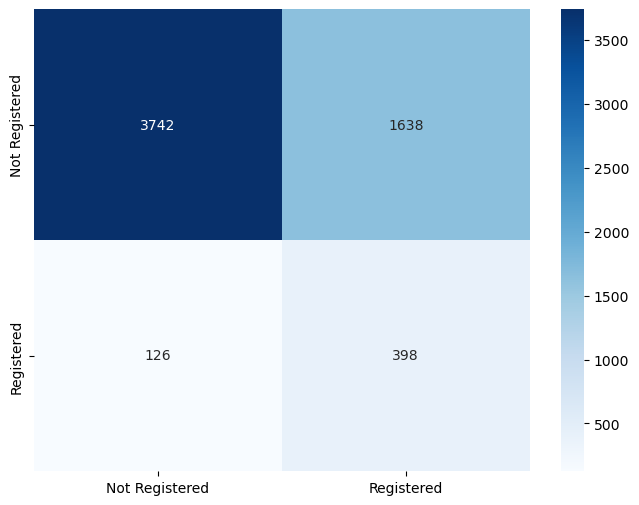

In [ ]:
# Train a logistic regression model.
# This model uses a maximum of 1000 iterations and a fixed random state.
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_resampled, y_train_resampled)

# Make predictions on the test set.
y_pred = lr.predict(X_test)
y_proba = lr.predict_proba(X_test)[:, 1]

# Evaluate model performance using accuracy and a classification report.
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print("Accuracy:", accuracy)
print("Classification Report:\n", report)

# Build the confusion matrix.
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix. Labels are provided for registered and not registered classes.
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Not Registered', 'Registered'],
    yticklabels=['Not Registered', 'Registered']
)
plt.show()

ROC AUC: 0.8213119696926701


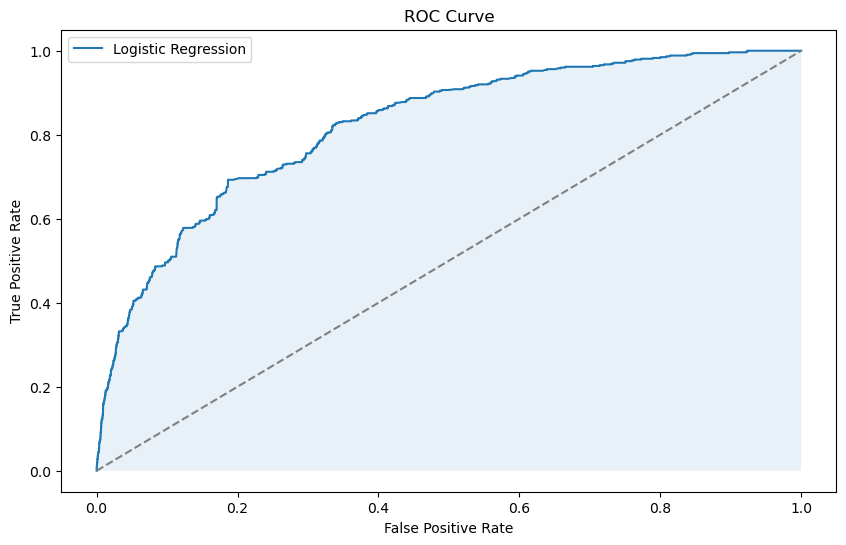

In [ ]:
# Calculate probability scores for predictions on test set.
y_proba = lr.predict_proba(X_test)[:, 1]

# Calculate ROC AUC score for model evaluation.
roc_auc = roc_auc_score(y_test, y_proba)
print("ROC AUC:", roc_auc)

# Calculate ROC curve points for plotting.
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

# Create ROC curve visualization.
plt.figure(figsize=(10, 6))

# Plot ROC curve with labeled model performance.
plt.plot(fpr, tpr, label='Logistic Regression')

# Add reference line for random classifier performance.
plt.plot([0, 1], [0, 1], color='grey', linestyle='--')

# Set axis labels for clarity.
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

# Add shaded area under the curve for visual emphasis.
plt.fill_between(fpr, tpr, alpha=0.1)

# Add legend to identify curve.
plt.legend()

# Add descriptive title.
plt.title('ROC Curve')

# Display the plot.
plt.show()

**Invetsigating the features that are most important in predicting student registration:**

In [ ]:
# Create a DataFrame with feature names and their corresponding coefficients.
# We sort the DataFrame by feature importance in descending order.
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': lr.coef_[0]
}).sort_values('Importance', ascending=False)

# Print the top 25 features with the highest importance.
print(feature_importance.head(25).reset_index(drop=True))

                          Feature  Importance
0                        Discount    1.395648
1             Nationality_Chinese    1.207762
2           Nationality_Taiwanese    1.132688
3                  Centre_Cardiff    0.751613
4            Nationality_Nepalese    0.729275
5                    Centre_Leeds    0.704612
6          Nationality_Sri Lankan    0.689048
7              Centre_Strathclyde    0.664959
8                   Centre_Sussex    0.550883
9              Nationality_Qatari    0.550483
10               Centre_Sheffield    0.524366
11                  Centre_Durham    0.464042
12            Centre_Huddersfield    0.451898
13          Nationality_Jordanian    0.433755
14              Nationality_Other    0.418563
15                IntakeQuarter_4    0.374716
16  Nationality_Hong Kong Chinese    0.374284
17                   Area_SE Asia    0.273514
18                  Centre_Surrey    0.265354
19              Nationality_Saudi    0.231550
20               Centre_Liverpool 

C:\Users\Emmanuel Wagaba\AppData\Local\Temp\ipykernel_37448\2867858100.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


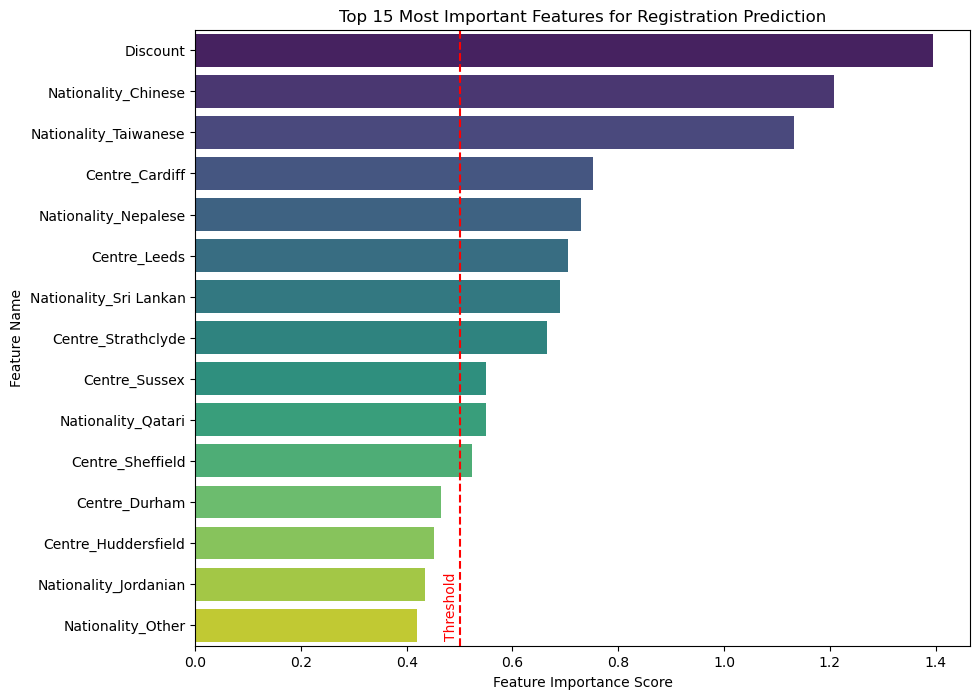

<Figure size 640x480 with 0 Axes>

In [ ]:
# Set the figure size for better visualisation.
plt.figure(figsize=(10, 8))

# Create horizontal bar chart for top 15 features by importance.
sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance.head(15),
    palette='viridis'
)

# Set descriptive axis labels.
plt.xlabel('Feature Importance Score')
plt.ylabel('Feature Name')

# Add a clear title to the visualisation.
plt.title('Top 15 Most Important Features for Registration Prediction')

# Add threshold line and label for reference.
plt.axvline(x=0.5, color='red', linestyle='--')
plt.text(
    x=0.47,
    y=14.3,
    s='Threshold',
    color='red',
    rotation=90
)

# Display the plot.
plt.show()

# Save the visualisation for later reference.
plt.savefig('feature_importance.png')

The feature importance bar chart above clearly shows which variables the logistic regression model relies on most when predicting student registrations. Features with higher positive importance scores (like Discount, Nationality_Chinese, Nationality_Taiwanese, Centre_Cardiff, and Centre_Leeds) indicate that these factors have a strong influence on the model’s decision process.

By identifying these key features, you can focus on refining and optimising the aspects that matter most:
- Adjust discount strategies to attract more registrations, given its high influence.
- Tailor marketing and enrollment efforts based on influential demographic and geographical features (e.g., nationalities and centres).
- Allocate resources efficiently by concentrating on areas associated with higher registration likelihood.

In summary, the chart provides evidence-based guidance to target improvements where they can have the greatest impact on increasing registration rates.

## **Important Features Model:**

**Training another logistic regression models on the important features:**

In [ ]:
# Create a new model with only the important features (those above threshold).
important_features = feature_importance[
    feature_importance['Importance'] > 0.5
]['Feature']

# Select important features from training and test sets.
X_train_important = X_train_resampled[important_features]
X_test_important = X_test[important_features]

# Train a new logistic regression model with important features.
lr_important = LogisticRegression(max_iter=1000, random_state=42)
lr_important.fit(X_train_important, y_train_resampled)

# Make predictions on the test set using important features.
y_pred_important = lr_important.predict(X_test_important)
y_proba_important = lr_important.predict_proba(X_test_important)[:, 1]

# Evaluate model performance using accuracy and classification metrics.
accuracy_important = accuracy_score(y_test, y_pred_important)
report_important = classification_report(y_test, y_pred_important)

# Display model performance metrics.
print("Accuracy (Important Features):", accuracy_important)
print("Classification Report (Important Features):\n", report_important)

Accuracy (Important Features): 0.7132452574525745
Classification Report (Important Features):
               precision    recall  f1-score   support

           0       0.97      0.71      0.82      5380
           1       0.20      0.75      0.32       524

    accuracy                           0.71      5904
   macro avg       0.58      0.73      0.57      5904
weighted avg       0.90      0.71      0.77      5904



**Evaluating the accuracy with a confusion_matrix:**

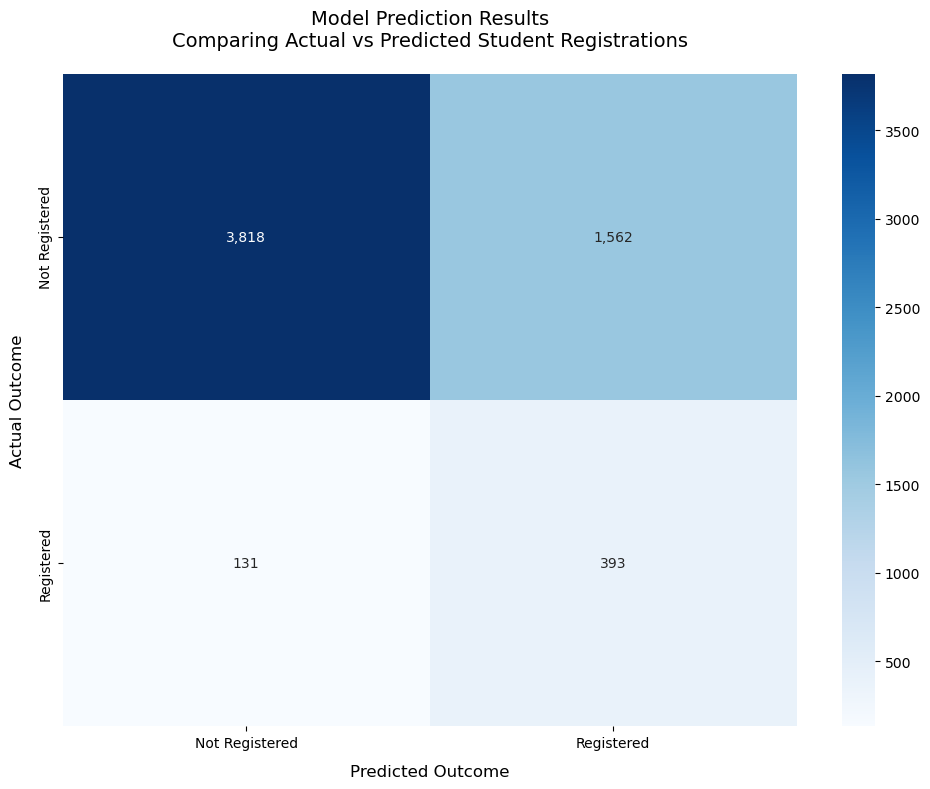

In [ ]:
# Build confusion matrix for the model using important features.
confusion_matrix_important = confusion_matrix(y_test, y_pred_important)

# Create a figure with dimensions optimised for readability.
plt.figure(figsize=(10, 8))

# Create a heatmap visualisation of the confusion matrix with custom formatting.
sns.heatmap(
    confusion_matrix_important,
    annot=True,
    fmt=',d',
    cmap='Blues',
    xticklabels=['Not Registered', 'Registered'],
    yticklabels=['Not Registered', 'Registered']
)

# Add clear axis labels for non-technical users.
plt.xlabel('Predicted Outcome', fontsize=12, labelpad=10)
plt.ylabel('Actual Outcome', fontsize=12, labelpad=10)

# Add an informative title explaining the visualisation.
plt.title(
    'Model Prediction Results\n'
    'Comparing Actual vs Predicted Student Registrations',
    pad=20,
    fontsize=14
)

# Adjust layout to prevent text overlap.
plt.tight_layout()

# Display the plot.
plt.show()

# Comparison of Confusion Matrix Results

**Pros of the Important Features Model:**
- The confusion matrix shows a slightly higher number of true negatives (3818 vs. 3742), which indicates a marginal improvement in correctly identifying non-registered students.
- Overall accuracy increased slightly (from about 70.1% to around 71.3%), suggesting that focusing on key predictors can retain most of the predictive power.


**Cons of the Important Features Model:**
- There is a slight drop in true positives (393 vs. 398) compared to the full model, which might affect the model’s ability to correctly identify registered students.
- The precision, recall, and F1-scores for the registered class remain relatively low, reflecting ongoing challenges in handling the class imbalance.
- Removing less important features might omit some nuanced information that benefits some edge-case predictions.

Overall, the trade-off between a simpler model and a small change in detection performance should be considered positive.

**Comparing ROC curves for both models:**

ROC AUC (Important Features): 0.7815421124322484


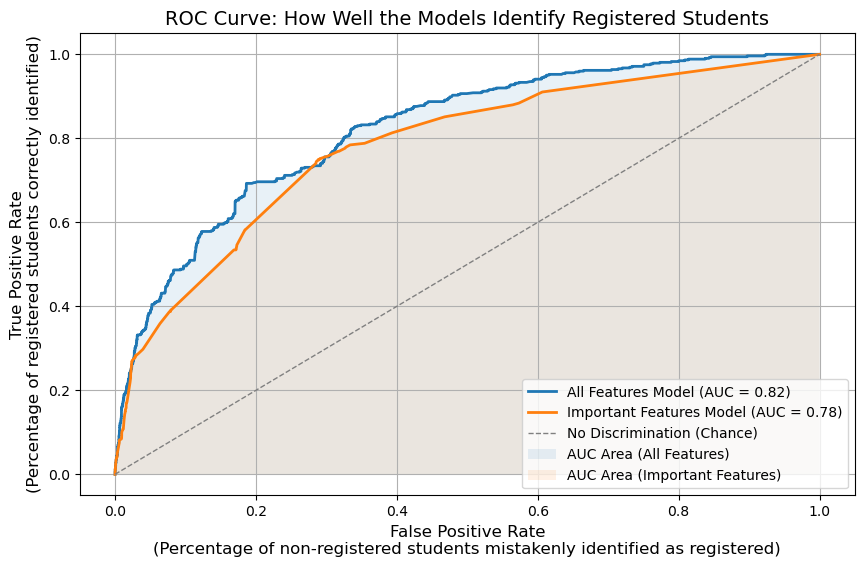

<Figure size 640x480 with 0 Axes>

In [ ]:
# Calculate ROC AUC for the important features model.
roc_auc_important = roc_auc_score(y_test, y_proba_important)
print("ROC AUC (Important Features):", roc_auc_important)

# Calculate ROC curves for both models.
fpr_all, tpr_all, _ = roc_curve(y_test, y_proba)
fpr_imp, tpr_imp, _ = roc_curve(y_test, y_proba_important)

# Create figure for ROC curve comparison.
plt.figure(figsize=(10, 6))

# Plot ROC curve for all features model.
plt.plot(
    fpr_all,
    tpr_all,
    label=f'All Features Model (AUC = {roc_auc:.2f})',
    lw=2
)

# Plot ROC curve for important features model.
plt.plot(
    fpr_imp,
    tpr_imp,
    label=f'Important Features Model (AUC = {roc_auc_important:.2f})',
    lw=2
)

# Add reference line for random classifier.
plt.plot(
    [0, 1],
    [0, 1],
    color='grey',
    linestyle='--',
    lw=1,
    label='No Discrimination (Chance)'
)

# Set descriptive axis labels.
plt.xlabel(
    'False Positive Rate\n'
    '(Percentage of non-registered students mistakenly identified as registered)',
    fontsize=12
)
plt.ylabel(
    'True Positive Rate\n'
    '(Percentage of registered students correctly identified)',
    fontsize=12
)

# Add informative title.
plt.title(
    'ROC Curve: How Well the Models Identify Registered Students',
    fontsize=14
)

# Fill areas under curves for better visualisation.
plt.fill_between(fpr_all, tpr_all, alpha=0.1, label='AUC Area (All Features)')
plt.fill_between(fpr_imp, tpr_imp, alpha=0.1, label='AUC Area (Important Features)')

# Add legend and grid.
plt.legend(fontsize=10)
plt.grid(True)

# Display the plot.
plt.show()

# Save the visualisation.
plt.savefig('roc_curve_important_features.png')

# ROC AUC Evaluation

The ROC AUC (Receiver Operating Characteristic Area Under the Curve) provides a measure of how well the model can distinguish between the two classes (registered vs. not registered). In our analysis, two models were evaluated:

- **All Features Model:**  
    The ROC AUC score is approximately 0.82. This indicates a strong capability to separate registered and non-registered students. A value close to 1 represents excellent discrimination.
- **Important Features Model:**  
    The ROC AUC score is approximately 0.78. Although slightly lower than the full model, this score still shows a reasonable performance with only the selected important features used for prediction.
- **Discrimination Power:**  
    A higher ROC AUC score means the model is better at correctly identifying instances belonging to the positive class (registered students) while avoiding false positives. This is crucial when the cost of misclassification is high.
- **Comparison of Models:**  
    In this case, the important features model retains a performance close to that of the full model, inferring that the features that were kept capture the essential information to decioher the differences.

Overall, the ROC AUC metrics provide a clear and quantitative basis for assessing model performance and making informed decisions on feature selection and model tuning.

# **Additional Visual Analyses:**

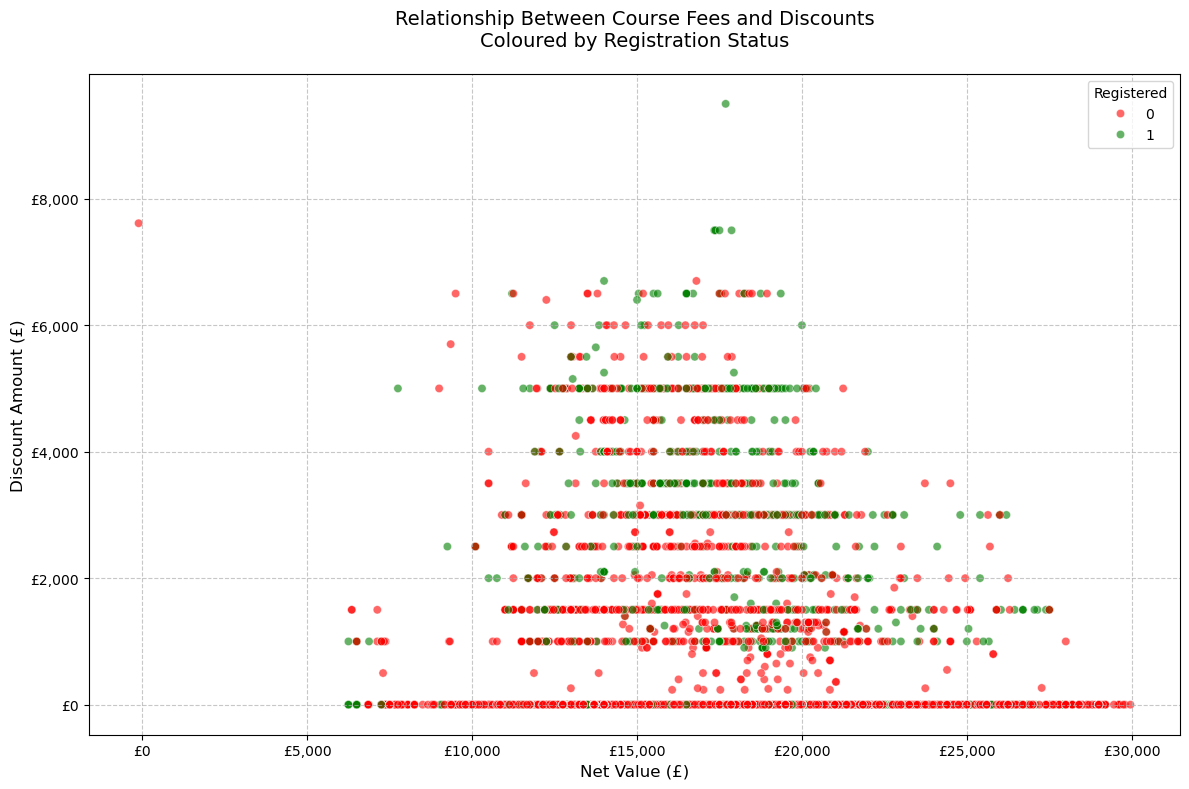

In [ ]:
# Create a figure for visualising the relationship between discounts and net value.
plt.figure(figsize=(12, 8))

# Create a scatter plot showing discount vs net value, coloured by registration status.
scatter = sns.scatterplot(
    data=unique_data,
    x='Net Value',
    y='Discount',
    hue='Registered',
    palette={0: 'red', 1: 'green'},
    alpha=0.6
)

# Add descriptive labels to the axes.
plt.xlabel('Net Value (£)', fontsize=12)
plt.ylabel('Discount Amount (£)', fontsize=12)

# Add a clear title describing the visualisation.
plt.title(
    'Relationship Between Course Fees and Discounts\nColoured by Registration Status',
    pad=20,
    fontsize=14
)

# Add a grid for better readability.
plt.grid(True, linestyle='--', alpha=0.7)

# Format axis labels to show thousand separator.
scatter.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'£{int(x):,}')
)
scatter.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'£{int(x):,}')
)

# Adjust layout to prevent text overlap.
plt.tight_layout()

# Display the plot.
plt.show()

Key Insights:
- Green points show successful registrations
- Red points show non-registrations
- Pattern shows relationship between fees, discounts and registration likelihood

C:\Users\Emmanuel Wagaba\AppData\Local\Temp\ipykernel_37448\3014914581.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


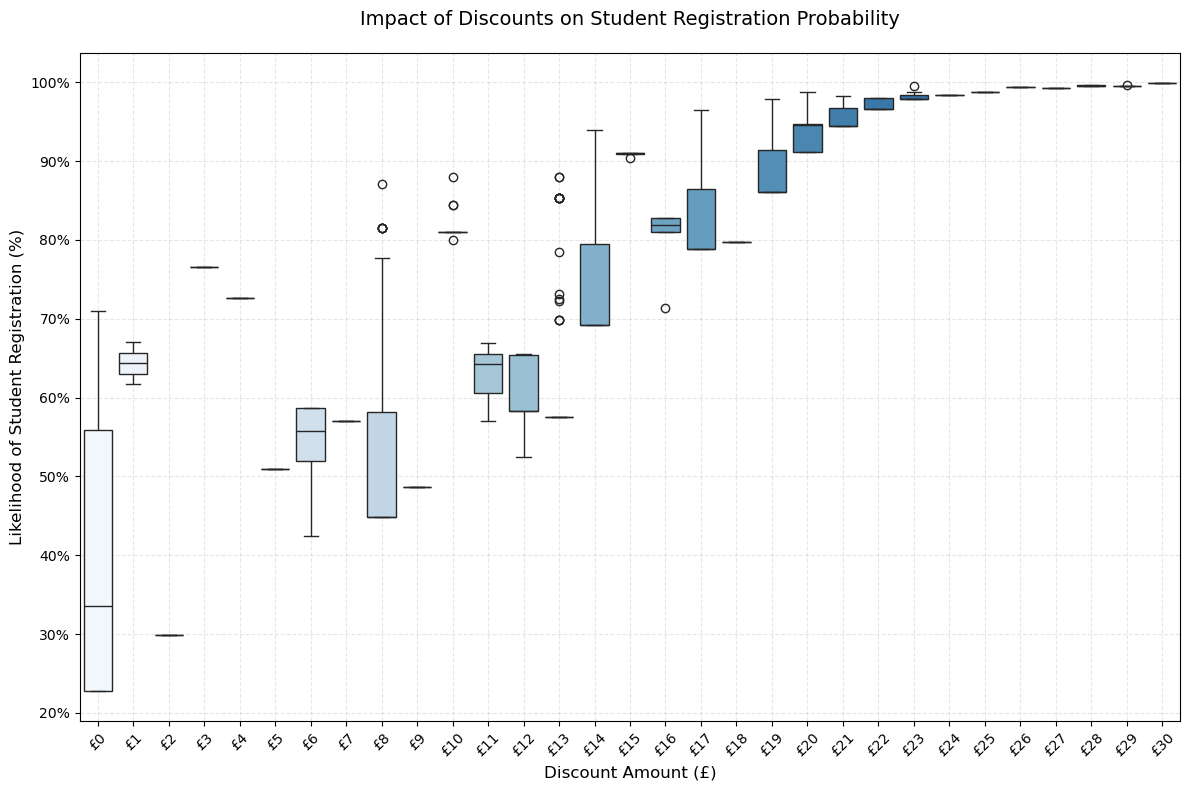

In [ ]:
# Create a clear visualisation of how discount values affect registration probability.
plt.figure(figsize=(12, 8))

# Create a box plot showing relationship between discounts and registration likelihood.
sns.boxplot(
    x='Discount',
    y=y_proba_important,
    data=X_test_important,
    palette='Blues'
)

# Add descriptive labels and title.
plt.xlabel('Discount Amount (£)', fontsize=12)
plt.ylabel('Likelihood of Student Registration (%)', fontsize=12)
plt.title(
    'Impact of Discounts on Student Registration Probability',
    pad=20,
    fontsize=14
)

# Format y-axis to show percentages.
plt.gca().yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y))
)

# Format x-axis to show pounds.
plt.gca().xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'£{int(x):,}')
)

# Add grid for better readability.
plt.grid(True, linestyle='--', alpha=0.3)

# Rotate x-axis labels for better visibility.
plt.xticks(rotation=45)

# Adjust layout to prevent text overlap.
plt.tight_layout()

# Display the plot.
plt.show()

**Using cross-validation to further evaluate the model:**

In [ ]:
# Check cross-validation score for model evaluation.
from sklearn.model_selection import cross_val_score

# Perform 5-fold cross-validation to assess model robustness.
cv_scores = cross_val_score(
    lr_important,
    X_train_important,
    y_train_resampled,
    cv=5,
    scoring='accuracy'
)

# Print the cross-validated scores for model performance analysis.
print("Cross-validated scores:", cv_scores)

Cross-validated scores: [0.71599045 0.74821002 0.70883055 0.70011947 0.72162485]


C:\Users\Emmanuel Wagaba\AppData\Local\Temp\ipykernel_37448\3702330883.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


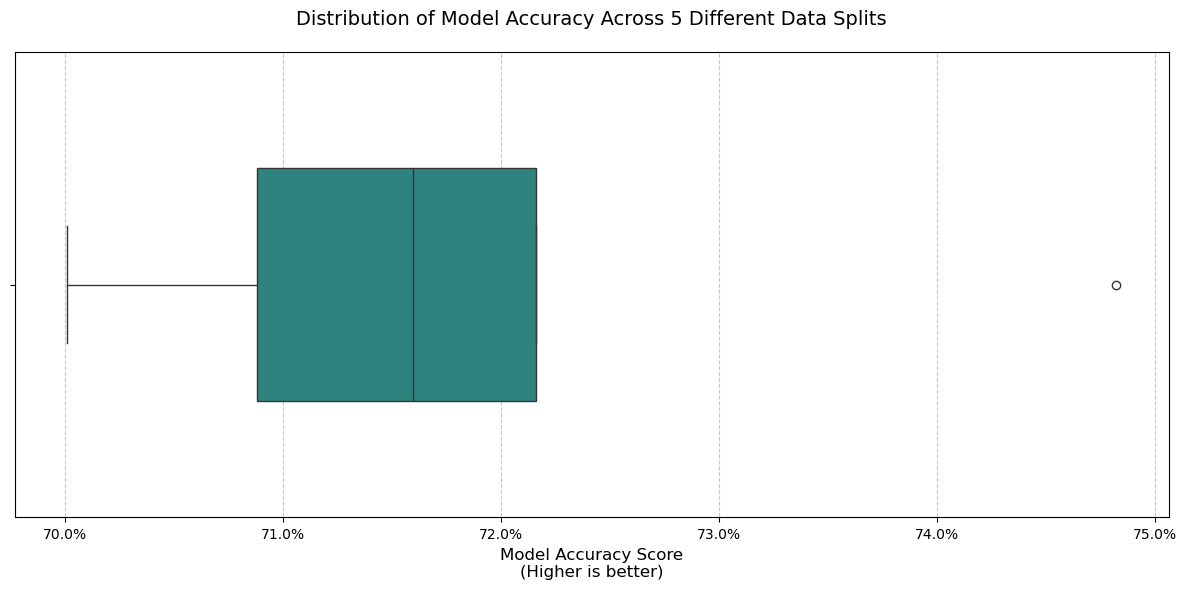

In [ ]:
# Create a figure with specified dimensions for better visibility.
plt.figure(figsize=(12, 6))

# Create box plot showing the distribution of model accuracy scores.
sns.boxplot(
    x=cv_scores,
    palette='viridis',
    width=0.5
)

# Add descriptive axis labels.
plt.xlabel(
    'Model Accuracy Score\n(Higher is better)',
    fontsize=12
)

# Add an informative title.
plt.title(
    'Distribution of Model Accuracy Across 5 Different Data Splits',
    pad=20,
    fontsize=14
)

# Format x-axis to show percentages.
plt.gca().xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: '{:.1%}'.format(x))
)

# Add grid for better readability.
plt.grid(True, axis='x', linestyle='--', alpha=0.7)

# Adjust layout to prevent text overlap.
plt.tight_layout()

# Display the plot.
plt.show()

# Model Accuracy and Cross-Validation Findings

The 5-fold cross-validation yielded accuracy scores of approximately 71.6%, 74.8%, 70.9%, 70.0%, and 72.2%. This consistency across folds indicates that the model generalises well to different subsets of the training data and that the selected important features provide a robust basis for predicting student registration.
The full logistic regression model achieved an accuracy of approximately 70.1%, while the important features model slightly improved to around 71.3%. This implies that the important features that I've selected, capture most of the predictive information, allowing a simpler model without compromising performance. The consistent cross-validation results further support the robustness of these predictions.

In [ ]:
def predict_registration(discount_thousands, nationality, centre):
    # Convert discount from thousands to full amount.
    discount_amount = discount_thousands * 1000

    # Scale discount (index 1 corresponds to 'Discount').
    scaled_discount = (discount_amount - scaler.mean_[1]) / scaler.scale_[1]

    # Build the feature vector.
    feat = {
        'Discount': scaled_discount,
        'Nationality_Chinese': nationality.strip().lower() == 'chinese',
        'Nationality_Taiwanese': nationality.strip().lower() == 'taiwanese',
        'Centre_Cardiff': centre.strip().lower() == 'cardiff',
        'Nationality_Nepalese': nationality.strip().lower() == 'nepalese',
        'Centre_Leeds': centre.strip().lower() == 'leeds',
        'Nationality_Sri Lankan': nationality.strip().lower() == 'sri lankan',
        'Centre_Strathclyde': centre.strip().lower() == 'strathclyde',
        'Centre_Sussex': centre.strip().lower() == 'sussex',
        'Nationality_Qatari': nationality.strip().lower() == 'qatari',
        'Centre_Sheffield': centre.strip().lower() == 'sheffield'
    }

    feature_order = [
        'Discount', 'Nationality_Chinese', 'Nationality_Taiwanese', 'Centre_Cardiff',
        'Nationality_Nepalese', 'Centre_Leeds', 'Nationality_Sri Lankan',
        'Centre_Strathclyde', 'Centre_Sussex', 'Nationality_Qatari',
        'Centre_Sheffield'
    ]

    input_df = pd.DataFrame(
        [[feat[feature] for feature in feature_order]], columns=feature_order
    )
    return lr_important.predict_proba(input_df)[0, 1]

**The "predict_registration" function estimates a student’s registration probability given a discount, nationality, and centre:**

In [ ]:
# Example usage of the prediction function.
# Students nationality is Qatari, and the centre is Sussex.
# Customise student discount.
probability = predict_registration(1.2, "Qatari", "Sussex")
print("Predicted registration probability: {:.2%}".format(probability))


Predicted registration probability: 72.97%


### **Using the predict_registration Function**

The `predict_registration` function estimates the probability that a student will register for a course based on three inputs. Below is an explanation of the function’s parameters and how to use it:

**How to input the parameters and the format:**
- Discount_thousands (float or int).
    -This number represents the discount value in thousands.
    - For example:
        - 0 = £0.00
        - 1 = £1,000
        - 2 = £2,000
        - etc
- Nationality (str).
    - A string that should specify the student's nationality
    - For example:
        - Chinese
        - Taiwanese
        - Nepalese
        - Sri Lankan
        - Qatari
- Centre (str):
    - A string indicating the centre's name
    - Similar to nationality, it specifies what Centre the student is applying for.
        - Cardiff
        - Leeds
        - Strathclyde
        - Sussex
        - Sheffield

# Notebook Findings and Their Impact on Registration Predictions

This notebook is a complete pipeline for analysing student enrolment data and predicting registration outcomes.

**How it can help enhance strategies:**

- **Predictive Insights:**  
    The logistic regression models identify key factors that drive student registration. This helps in understanding the underlying determinants of successful enrolments and informs improvements in registration processes.
- **Feature Importance Relevance:**  
    The feature importance analysis highlights elements such as discount levels, nationality, and centre locations as significant predictors. Recognising these drivers allows for targeted interventions to enhance registration rates.
- **Balanced Modelling Approach:**  
    Addressing class imbalance through resampling ensures that the model accurately reflects both the registered and non-registered populations. This leads to more robust and unbiased predictions.
- **Robust Evaluation Metrics:**  
    Utilising metrics such as accuracy, ROC AUC, confusion matrices, and cross-validation scores provides a comprehensive evaluation of model performance. Comparing models trained on all features versus only the important features offers clear insights into the critical drivers of registration.
- **Actionable Results:**  
    Visual tools, including ROC curves and confusion matrices, facilitate a clear understanding of the model’s predictive power. These insights can be used to refine the registration strategy and deploy resources more effectively to boost successful enrolments.
- **Prediction Function:**  
    Finally a function that can assist in deciding the optimal discount for the demographics available in the datset provided.
